<a href="https://colab.research.google.com/github/adibakhushboo/Skill-Craft-Technology-Internship/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'us-accidents' dataset.
Dataset downloaded to: /kaggle/input/us-accidents
Files in folder: ['US_Accidents_March23.csv']

FIRST 5 ROWS
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.1883

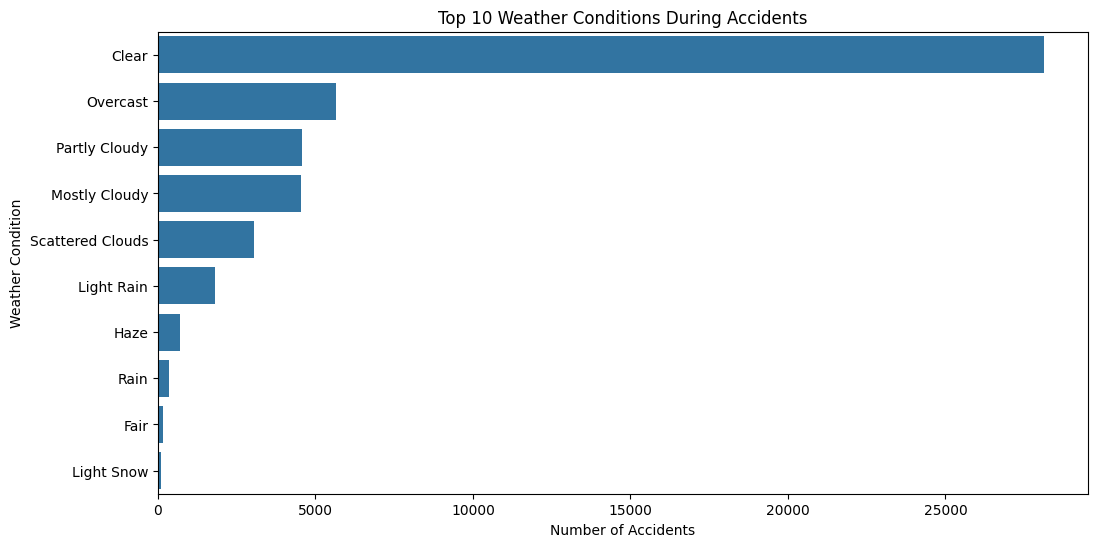

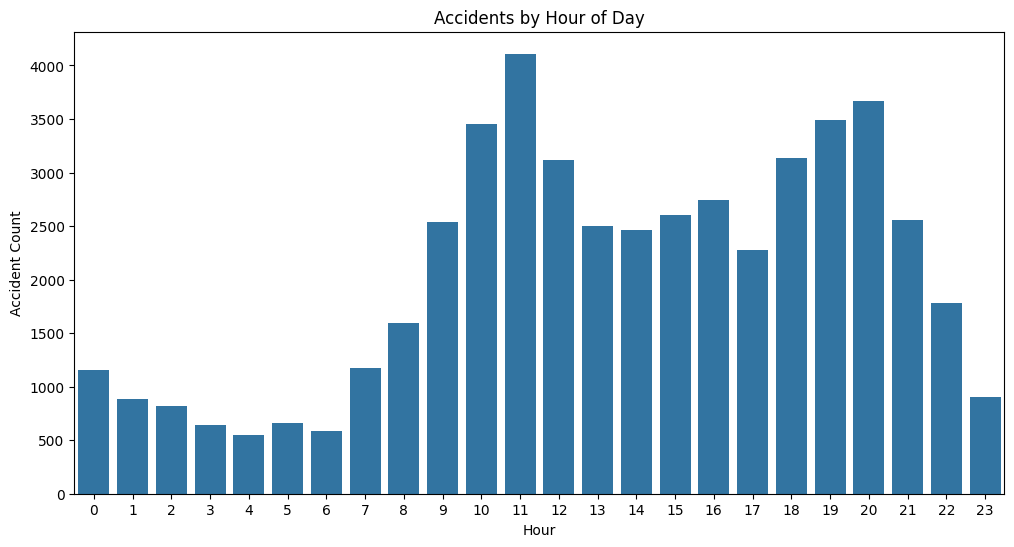

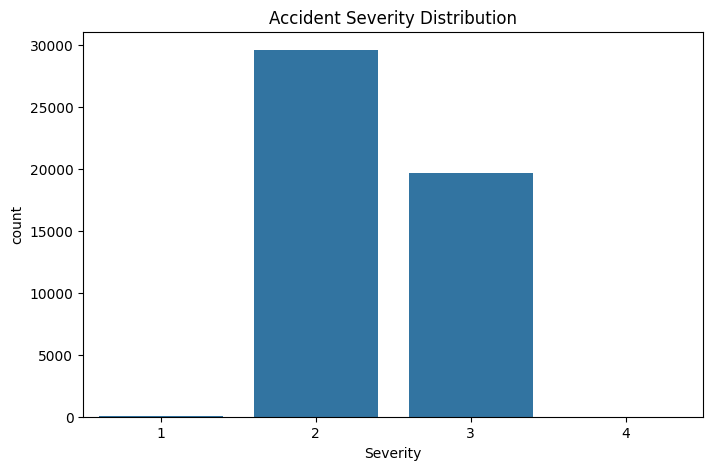

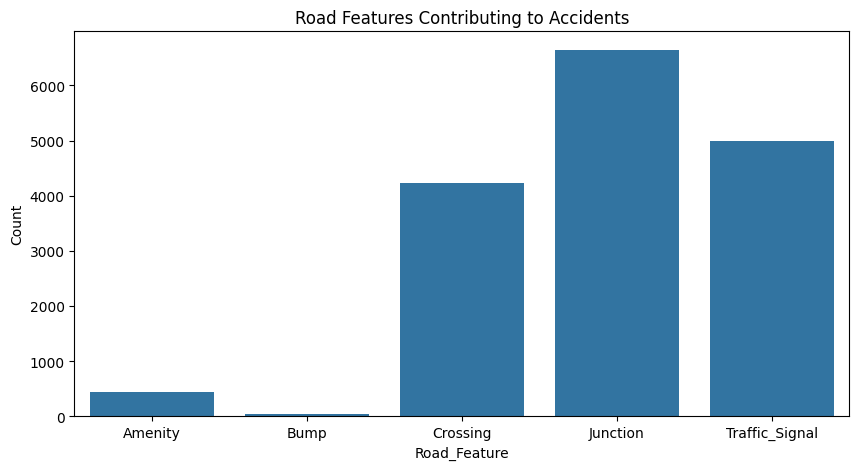

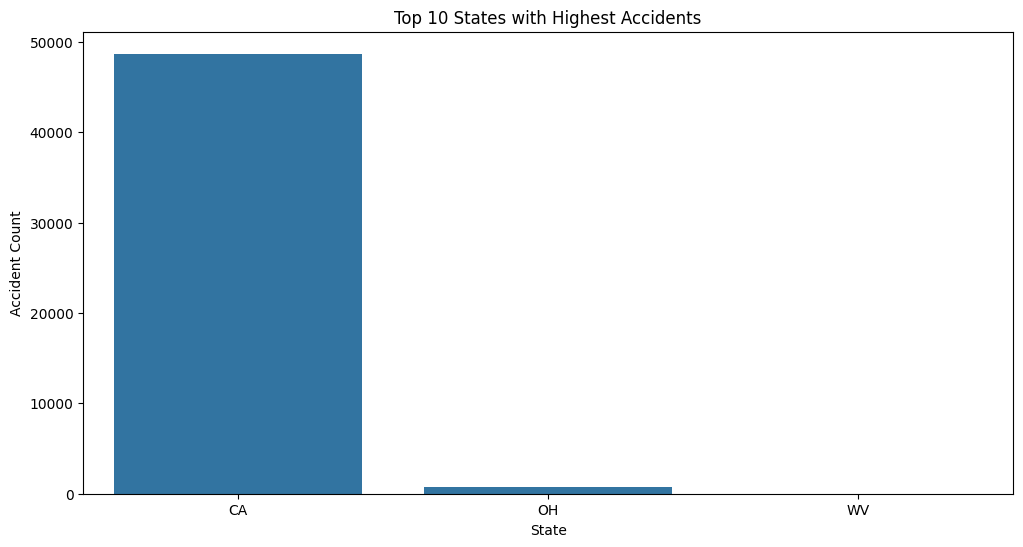

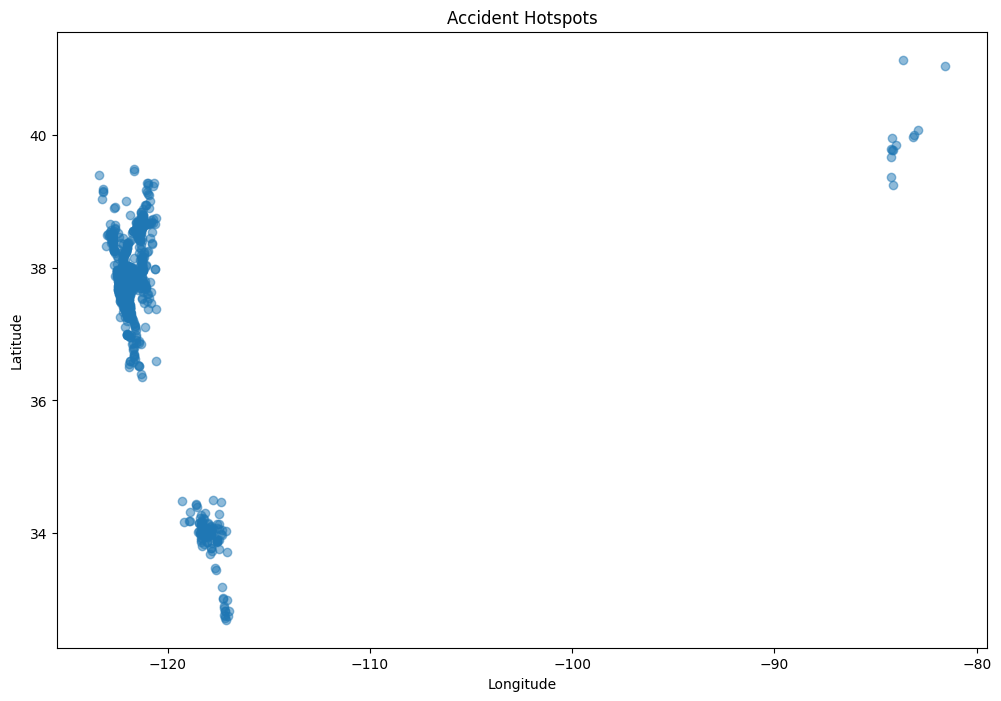

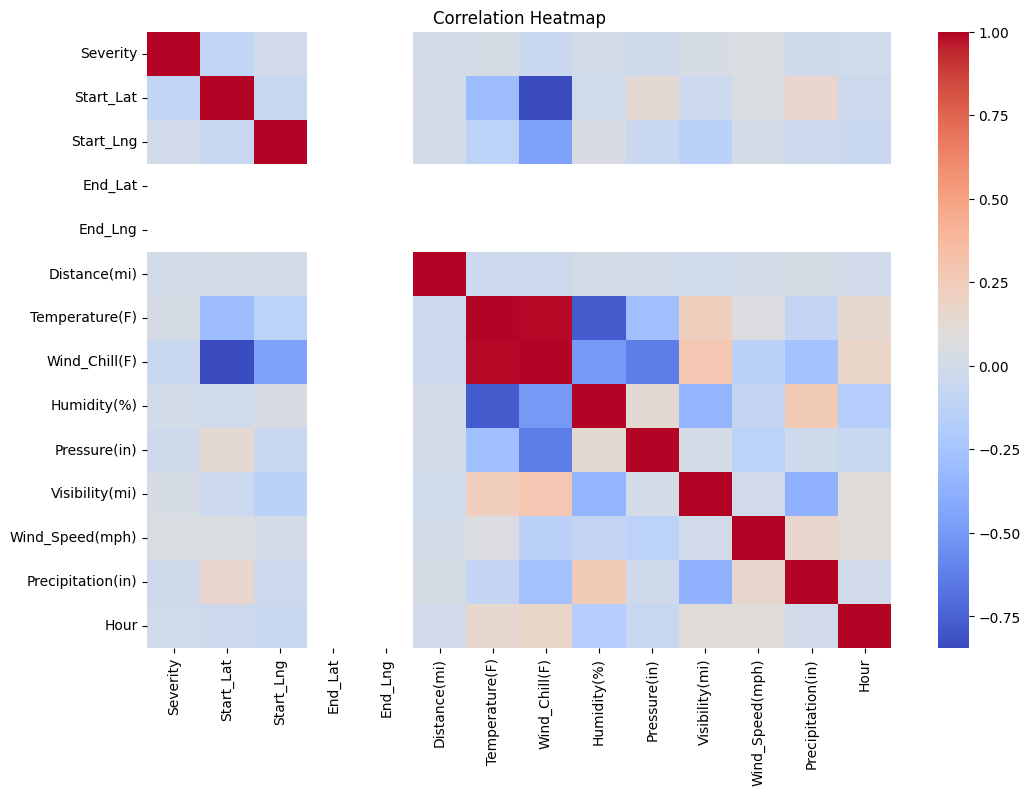


KEY OBSERVATIONS:
1. Most accidents happened during certain weather conditions.
2. Accident frequency changes with time of day.
3. Some road features contribute more to accidents.
4. Certain states recorded more accidents.
5. Accident hotspots can be identified using coordinates.

CONCLUSION:
Traffic accident analysis helped identify patterns
related to weather, road conditions, and time.
Visualizations revealed accident hotspots
and major contributing factors.


In [ ]:
# TASK 04 - Analyze traffic accident data
# INSTALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# DOWNLOAD DATASET

path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Dataset downloaded to:", path)

# LOAD DATASET

files = os.listdir(path)
print("Files in folder:", files)

csv_path = os.path.join(path, "US_Accidents_March23.csv")

# LOAD ONLY 50,000 ROWS FOR FASTER EXECUTION

df = pd.read_csv(csv_path, nrows=50000)

# DISPLAY DATASET

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# DATA CLEANING

df = df.dropna(subset=['Weather_Condition'])

df['Visibility(mi)'] = df['Visibility(mi)'].fillna(
    df['Visibility(mi)'].median()
)

df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour

print("\nDATA CLEANING COMPLETED")

# ACCIDENTS BY WEATHER CONDITION

top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

plt.show()

# ACCIDENTS BY HOUR OF DAY

plt.figure(figsize=(12,6))

sns.countplot(x='Hour', data=df)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Accident Count")

plt.show()

# ACCIDENT SEVERITY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title("Accident Severity Distribution")

plt.show()

# ROAD CONDITION ANALYSIS

road_columns = [
    'Amenity',
    'Bump',
    'Crossing',
    'Junction',
    'Traffic_Signal'
]

road_counts = []

for col in road_columns:
    road_counts.append(df[col].sum())

road_df = pd.DataFrame({
    'Road_Feature': road_columns,
    'Count': road_counts
})

plt.figure(figsize=(10,5))

sns.barplot(
    x='Road_Feature',
    y='Count',
    data=road_df
)

plt.title("Road Features Contributing to Accidents")

plt.show()

# TOP STATES WITH ACCIDENTS

top_states = df['State'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top 10 States with Highest Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")

plt.show()

# ACCIDENT HOTSPOTS

sample_df = df.sample(1000)

plt.figure(figsize=(12,8))

plt.scatter(
    sample_df['Start_Lng'],
    sample_df['Start_Lat'],
    alpha=0.5
)

plt.title("Accident Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# CORRELATION HEATMAP

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# OBSERVATIONS

print("\nKEY OBSERVATIONS:")
print("1. Most accidents happened during certain weather conditions.")
print("2. Accident frequency changes with time of day.")
print("3. Some road features contribute more to accidents.")
print("4. Certain states recorded more accidents.")
print("5. Accident hotspots can be identified using coordinates.")

# CONCLUSION

print("\nCONCLUSION:")
print("Traffic accident analysis helped identify patterns")
print("related to weather, road conditions, and time.")
print("Visualizations revealed accident hotspots")
print("and major contributing factors.")